Title: Analyse exploratoire de données (EDA)
Authors : 
  "Author1": Alpha Boubacar DIALLO 
  "Author2": Rayane DJEMA

In [37]:
import numpy as np
import pandas as pd


import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


import random 
from tqdm.auto import tqdm

import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [38]:
sns.__version__

'0.13.2'

<hr>
<h2>Description</h2>
<p>Le jeu de données contenu dans train.csv décrit des candidatures au poste de
chercheur d’or chez OrFée.<br>

<p>Le jeu de données comporte 12 colonnes :<br>
• <b>id</b>  : identifiant unique de chaque ligne<br>
• <b>date</b>  : date de la candidature<br>
•  <b>age</b>: âge du candidat<br>
•  <b>diplome</b>: plus haut diplôme obtenu (bac, licence, master, doctorat)<br>
• <b>specialite</b> : spécialité du diplôme (géologie, forage, détective, archéologie, . . . )<br>
• <b>salaire</b>: salaire demandé<br>
• <b>dispo</b>: oui : disponibilité immédiate, non : pas disponible immédiatement<br>
• <b>sexe</b>: féminin (F) ou masculin (M)<br>
• <b>exp</b> : nombre d’années d’expérience<br>
• <b>cheveux</b> : couleur des cheveux (châtain, brun, blond, roux)<br>
• <b>note</b> : note (sur 100) obtenue à l’exercice de recherche d’or<br>
• <b>embauche</b> : le candidat a-t-il été embauché ? (0 : non, 1 : oui) <br>

In [39]:
df = pd.read_csv(r'../data/data.csv',sep=',')  # ou sep="," selon ton fichier
df.shape

(20000, 11)

In [40]:
df["cheveux"].value_counts()

cheveux
chatain    6020
brun       5985
blond      5927
roux       1953
             10
Name: count, dtype: int64

In [41]:
df.columns

Index(['date', 'cheveux', 'age', 'exp', 'salaire', 'sexe', 'diplome',
       'specialite', 'note', 'dispo', 'embauche'],
      dtype='object')

# <span style="color:#011C5D">Analyse descriptive </span>

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        19909 non-null  object 
 1   cheveux     19895 non-null  object 
 2   age         19909 non-null  object 
 3   exp         19904 non-null  object 
 4   salaire     19905 non-null  object 
 5   sexe        19900 non-null  object 
 6   diplome     19891 non-null  object 
 7   specialite  19907 non-null  object 
 8   note        19886 non-null  float64
 9   dispo       19894 non-null  object 
 10  embauche    20000 non-null  int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 1.7+ MB


### <span style="color:#011C5D">1. Identifier les variables numeriques et categorielles </span>

In [43]:
# EXERCICE : 

# Identifions tout d'abord les colonnes catégorielles
col_categoricals = ["cheveux", "diplome",  "dispo", "sexe", "specialite", "embauche"] 
# Puis les numériques
col_numericals = ["note", "exp", "age", "salaire"]


print(f"Liste des colonnes catégorielles :\n{col_categoricals}")
print(f"\nListe des colonnes numériques :\n{col_numericals}")

Liste des colonnes catégorielles :
['cheveux', 'diplome', 'dispo', 'sexe', 'specialite', 'embauche']

Liste des colonnes numériques :
['note', 'exp', 'age', 'salaire']


In [44]:
# Convertir les données numerique au bon format "SI BESOIN"
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["exp"] = pd.to_numeric(df["exp"], errors="coerce")
df["salaire"] = pd.to_numeric(df["salaire"], errors="coerce")
df["embauche"] = df["embauche"].astype("string")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        19909 non-null  object 
 1   cheveux     19895 non-null  object 
 2   age         19899 non-null  float64
 3   exp         19894 non-null  float64
 4   salaire     19895 non-null  float64
 5   sexe        19900 non-null  object 
 6   diplome     19891 non-null  object 
 7   specialite  19907 non-null  object 
 8   note        19886 non-null  float64
 9   dispo       19894 non-null  object 
 10  embauche    20000 non-null  string 
dtypes: float64(4), object(6), string(1)
memory usage: 1.7+ MB


### <span style="color:#011C5D">2. Analyse de la distribution des variables numeriques </span>

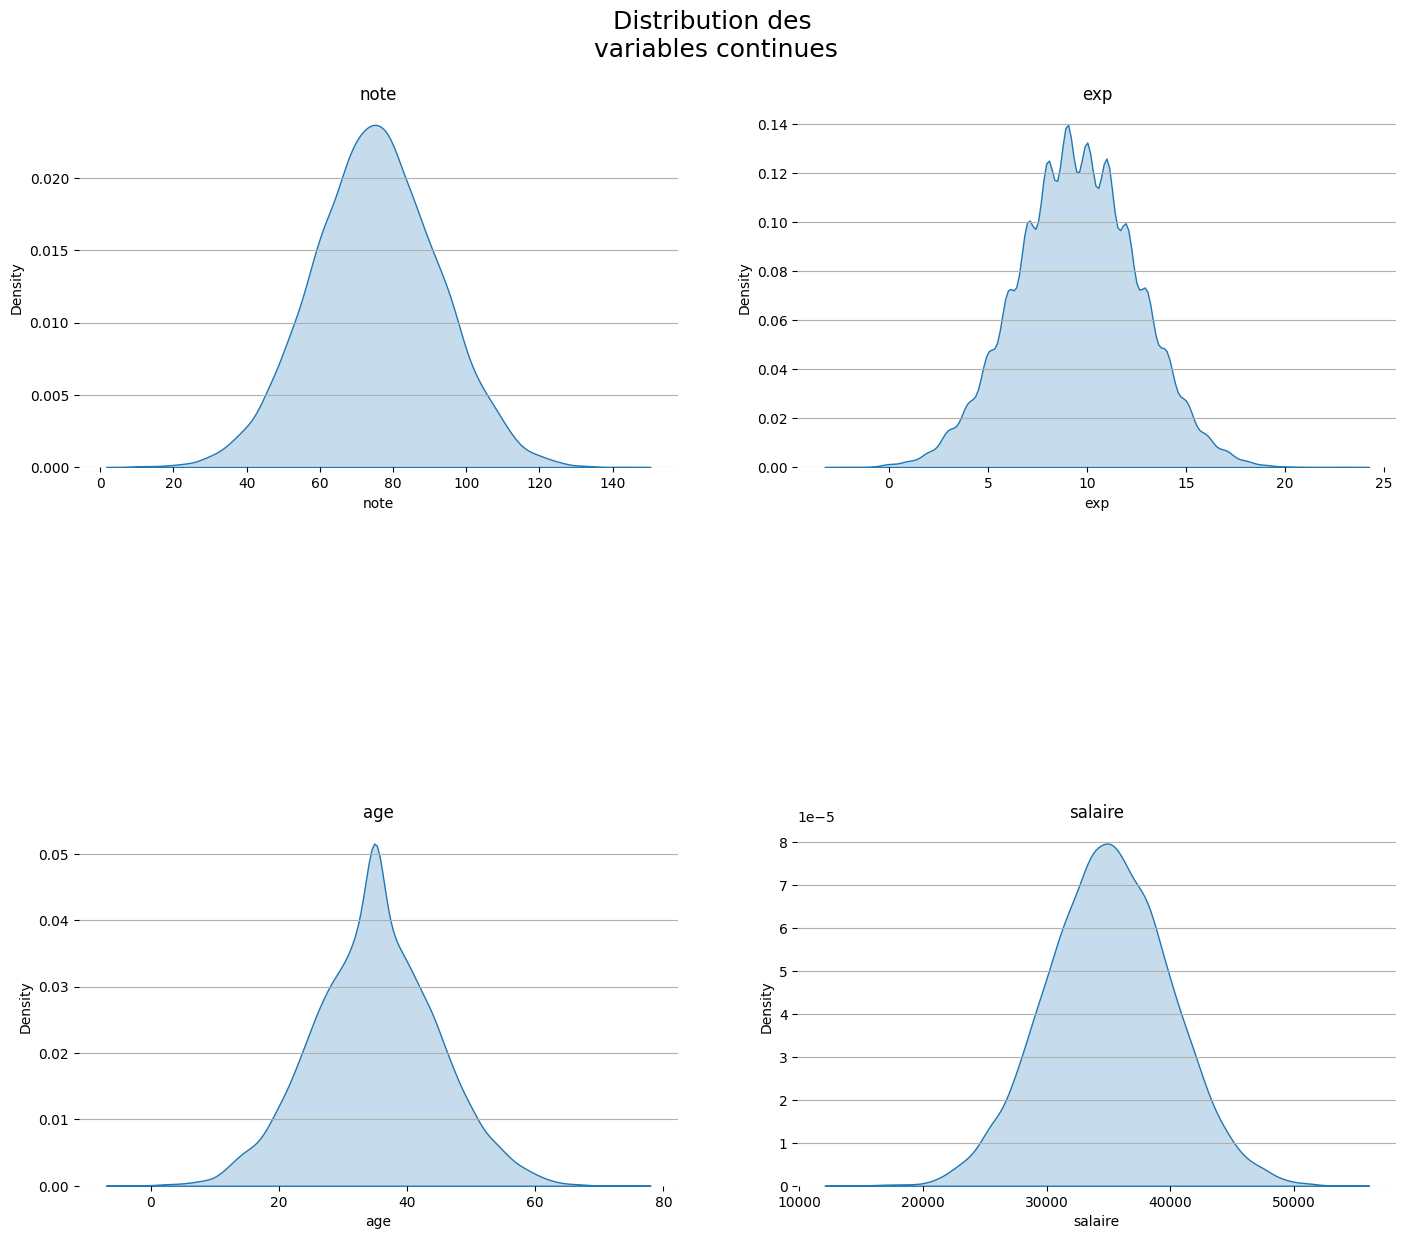

In [45]:
ncols = 2
nrows = len(col_numericals) // ncols + (len(col_numericals) % ncols > 0)
 
plt.figure(figsize=(17, 14))
plt.subplots_adjust(hspace=1)
plt.suptitle("Distribution des \nvariables continues", fontsize=18, y=0.95)
 
for n, variable in enumerate(col_numericals):
    # add a new subplot iteratively
    ax = plt.subplot(nrows, ncols, n + 1)
 
    sns.kdeplot(ax=ax, data=df[variable], legend=None, shade=True)
    ax.grid(True, which='major', axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    ax.set_title(variable, loc= 'center', fontsize=12)

### <span style="color:#011C5D">3. Matrice de correlation </span>

In [46]:
# EXERCICE : 

# Calculer la correlation entre les variables numeriques

matrice_corr = df[col_numericals].corr()

# Afficher un heatmap de la matrice de correlation 
matrice_corr


# Que pouvez-vous conclure ?

,note,exp,age,salaire
note,1.000000,-0.012099,-0.007574,-0.448243
exp,-0.012099,1.000000,-0.003063,0.010020
age,-0.007574,-0.003063,1.000000,0.001001
salaire,-0.448243,0.010020,0.001001,1.000000


La matrice de corrélation met en évidence une relation négative modérée entre la note et le salaire demandé, ce qui est surprenant car on pourrait attendre l’inverse dans la réalité. Les autres variables numériques (âge, expérience, salaire) n’affichent quasiment aucune corrélation entre elles. Cela montre que les relations linéaires entre ces variables sont faibles et que d’autres facteurs (catégorielles, interactions) seront sans doute plus explicatifs pour l’embauche

### <span style="color:#011C5D">4. Identification des valeurs manquantes </span>

In [47]:
# EXERCICE : Laissez libre court à votre créativité et créez une fonction qui affiche le taux
#            de valeurs manquantes de chaque variable pour chaque type (catégorielle et numérique)
#            par ordre décroissant


def display_missing_values(df):
    # Calcul du pourcentage de valeurs manquantes pour chaque colonne
    missing_rate = (df.isnull().sum() / len(df)) * 100
    missing_rate = missing_rate.sort_values(ascending=False)
    
    # Séparer les variables selon leur type
    num_cols = df.select_dtypes(include=['number']).columns
    cat_cols = df.select_dtypes(exclude=['number']).columns

    print(" Variables NUMÉRIQUES")
    display(missing_rate[num_cols][missing_rate[num_cols] > 0])
    print("\n Variables CATÉGORIELLES ")
    display(missing_rate[cat_cols][missing_rate[cat_cols] > 0])

display_missing_values(df)
# Que pouvez-vous conclure ?

 Variables NUMÉRIQUES


age        0.505
exp        0.530
salaire    0.525
note       0.570
dtype: float64


 Variables CATÉGORIELLES 


date          0.455
cheveux       0.525
sexe          0.500
diplome       0.545
specialite    0.465
dispo         0.530
dtype: float64

Le dataset est très peu incomplet (~0,5–0,6 % de valeurs manquantes par colonne).

In [48]:
print(df.isnull().sum()) # verification des calculs de la fonction 

print(df.count())

date           91
cheveux       105
age           101
exp           106
salaire       105
sexe          100
diplome       109
specialite     93
note          114
dispo         106
embauche        0
dtype: int64
date          19909
cheveux       19895
age           19899
exp           19894
salaire       19895
sexe          19900
diplome       19891
specialite    19907
note          19886
dispo         19894
embauche      20000
dtype: int64


### <span style="color:#011C5D">5. Imputation des valeurs manquantes </span>

#### <span style="color:#011C5D">5.1 Variables numeriques </span>

##### <span style="color:#011C5D">5.1.1 Imputation par la moyenne </span>

In [49]:
# EXERCICE : Imputation des variables numériques avec la moyenne
# Les variables imputées sont enregistrées dans de nouvelles colonnes.

for col in df.select_dtypes(include = [np.number]).columns :
    mean_value=df[col].mean()
    df[col + "_imputed_by_mean"] = df[col].fillna(mean_value)

df.head()

,date,cheveux,age,exp,salaire,sexe,diplome,specialite,note,dispo,embauche,age_imputed_by_mean,exp_imputed_by_mean,salaire_imputed_by_mean,note_imputed_by_mean
0,02/06/2012,roux,25.0,9.0,26803.0,F,licence,geologie,97.08,non,0,25.000000,9.0,26803.0,97.08
1,21/04/2011,blond,35.0,13.0,38166.0,M,licence,forage,63.86,non,0,35.000000,13.0,38166.0,63.86
2,07/09/2012,blond,29.0,13.0,35207.0,M,licence,geologie,78.50,non,0,29.000000,13.0,35207.0,78.50
3,01/07/2011,brun,NaN,12.0,32442.0,M,licence,geologie,45.09,non,0,35.004473,12.0,32442.0,45.09
4,07/08/2012,roux,35.0,6.0,28533.0,F,licence,detective,81.91,non,0,35.000000,6.0,28533.0,81.91


##### <span style="color:#011C5D">5.1.2 Imputation par la regression </span>

In [50]:
#EXERCICE : Imputation par régression
# Laissez libre cours à votre créativité !
# Pour chaque variable numérique contenant des valeurs manquantes, utilisez les variables explicatives 
#appropriées afin d’imputer les valeurs manquantes à l’aide d’une méthode de régression.

import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

cat_cols_all = [c for c in col_categoricals if c != "embauche"]  # on n'utilise pas la cible
num_cols_all = col_numericals[:]

# 2) Mapping "variable cible -> variables explicatives appropriées"
feature_map = {
    "salaire":   ["age", "exp", "note"],
    "age":       ["exp",  "salaire", "note"],
    "exp":       ["age", "salaire", "note"],
    "note":      ["salaire", "age", "exp"],
}

# 3) Petite fonction générique
def impute_target_with_reg(df, target_col, features):
    # Sépare numériques et catégorielles dans les "features"
    num_feats = [c for c in features if c in num_cols_all]
    cat_feats = [c for c in features if c in cat_cols_all]

    # Lignes connues / manquantes
    known_idx = df[target_col].notna()
    miss_idx  = df[target_col].isna()
    
    out_col = f"{target_col}_imp_reg"
    df[out_col] = df[target_col]  # copie de la colonne originale
    if miss_idx.sum() == 0:
        return df  # rien à imputer

    X_train = df.loc[known_idx, num_feats + cat_feats]
    y_train = df.loc[known_idx, target_col]
    X_test  = df.loc[miss_idx,  num_feats + cat_feats]

    pre = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_feats),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
        ],
        remainder="drop"
    )

    model = LinearRegression()
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X_train, y_train)
    df.loc[miss_idx, out_col] = pipe.predict(X_test)
    return df

# 4) Application ciblée : uniquement si la colonne a des NaN
for target, feats in feature_map.items():
    if target in df.columns and df[target].isna().any():
        df = impute_target_with_reg(df, target, feats)

# 5) Contrôle
imputed_cols = [c for c in df.columns if c.endswith("_imp_reg")]
print("Colonnes imputées :", imputed_cols)
print("NaN restants sur colonnes imputées :")
print(df[imputed_cols].isna().sum())



Colonnes imputées : ['salaire_imp_reg', 'age_imp_reg', 'exp_imp_reg', 'note_imp_reg']
NaN restants sur colonnes imputées :
salaire_imp_reg    0
age_imp_reg        0
exp_imp_reg        0
note_imp_reg       0
dtype: int64


##### <span style="color:#011C5D">5.1.3 Comparer la distribution des variables imputer </span>

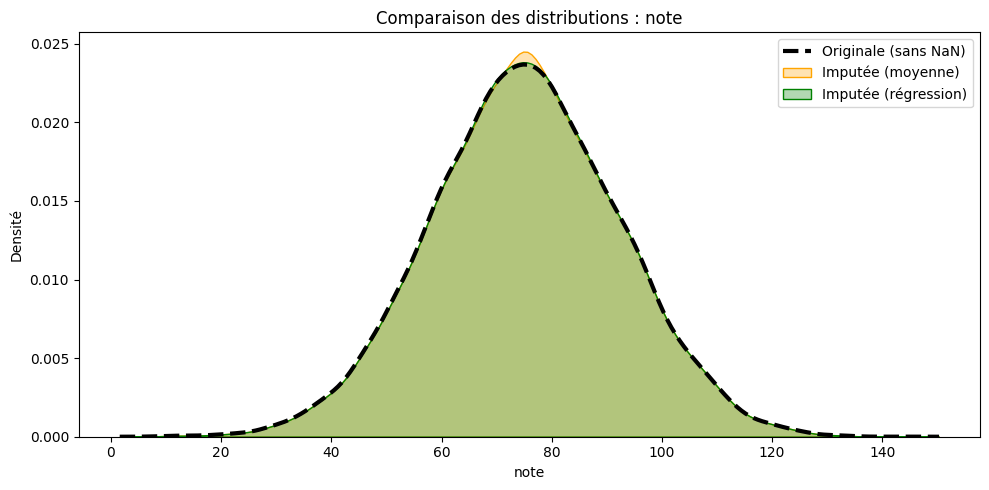

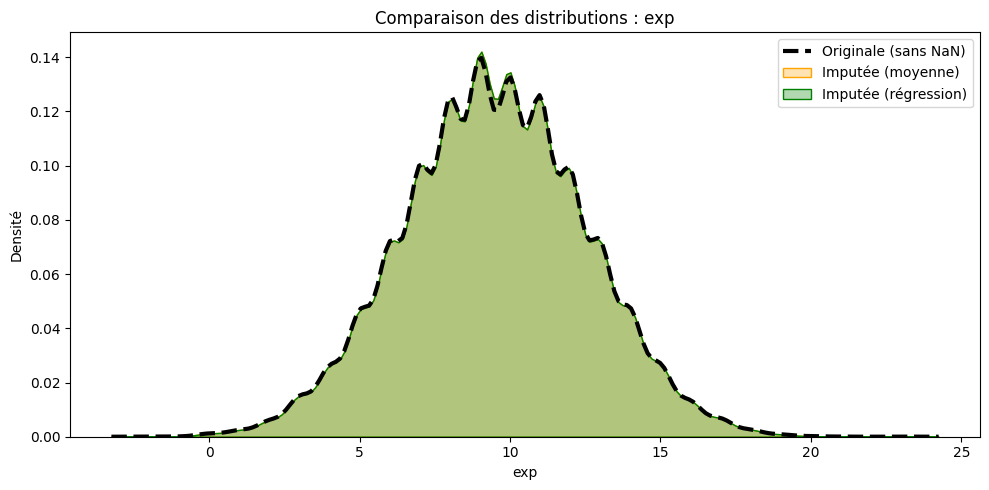

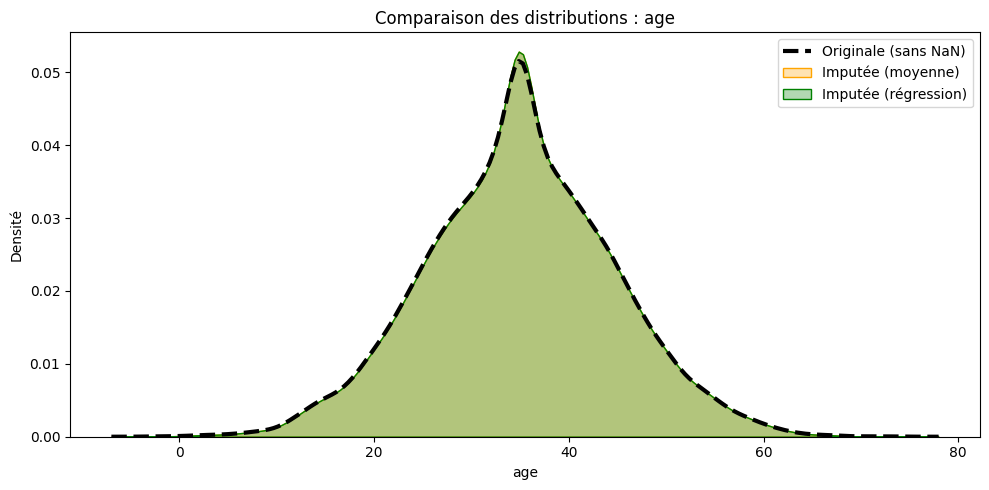

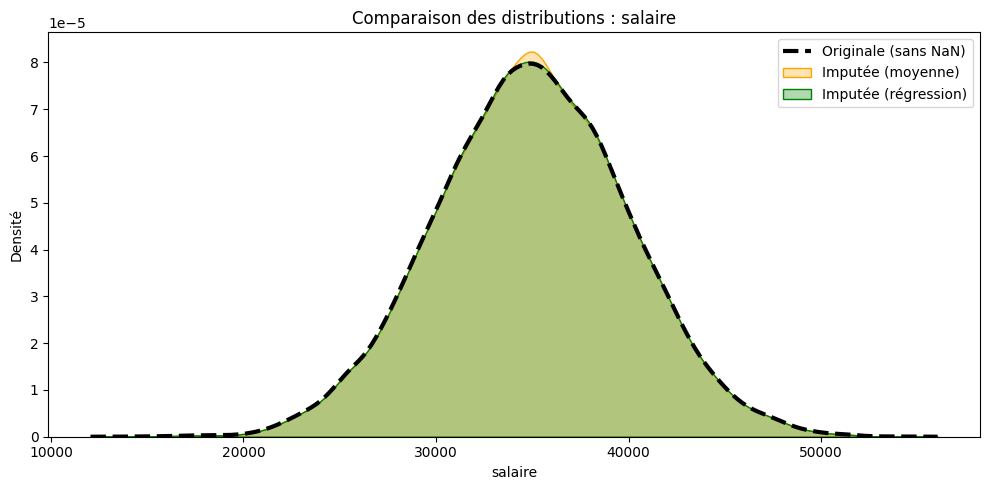

In [51]:
# EXERCICE : Laissez libre court à votre créativité 
# Pour chaque variable numerique
# Comparer la distribution entre l'imputation par la moyenne et l'imputation par Regression

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["note", "exp", "age", "salaire"]

for col in num_cols:
    plt.figure(figsize=(10,5))
    mean_col = col + "_imputed_by_mean"
    reg_col  = col + "_imp_reg"

    # Originale (ligne pointillée, épaisse)
    if col in df.columns:
        sns.kdeplot(df[col].dropna(), label="Originale (sans NaN)", linewidth=3, linestyle="--", color="black")

    # Imputation par moyenne (remplissage léger)
    if mean_col in df.columns:
        sns.kdeplot(df[mean_col], label="Imputée (moyenne)", fill=True, alpha=0.3, color="orange")

    # Imputation par régression (remplissage léger)
    if reg_col in df.columns:
        sns.kdeplot(df[reg_col], label="Imputée (régression)", fill=True, alpha=0.3, color="green")

    plt.title(f"Comparaison des distributions : {col}")
    plt.xlabel(col)
    plt.ylabel("Densité")
    plt.legend()
    plt.tight_layout()
    plt.show()







On observe que l’imputation par la moyenne, bien que simple, introduit une déformation visible des distributions : les valeurs manquantes sont concentrées artificiellement autour de la moyenne, ce qui réduit la variabilité et peut biaiser les analyses.
En revanche, l’imputation par régression conserve beaucoup mieux la forme initiale des distributions, car elle utilise l’information des autres variables pour prédire les valeurs manquantes.
Ainsi, même si la moyenne est une solution rapide, la régression apparaît comme une méthode plus robuste et plus fidèle aux données originales.

#### <span style="color:#011C5D">5.2 Variables categorielles </span>

In [52]:
# EXERCICE : Utiliser une methode adequate pour imputer les variables categorielles
# Les variables imputées sont enregistrées dans de nouvelles colonnes.

if "embauche_imputed_by_mode" in df.columns:
    df = df.drop(columns=["embauche_imputed_by_mode"])





In [53]:
print(col_categoricals)


['cheveux', 'diplome', 'dispo', 'sexe', 'specialite', 'embauche']


In [54]:
# Liste des variables catégorielles à imputer (hors cible 'embauche')
col_categoricals = ["cheveux", "diplome", "dispo", "sexe", "specialite"]

# Imputation par le mode (valeur la plus fréquente)
for col in col_categoricals:
    mode_value = df[col].mode()[0]  # valeur la plus fréquente
    df[col + "_imputed_by_mode"] = df[col].fillna(mode_value)

# Vérification
print("Colonnes imputées :", [c for c in df.columns if "_imputed_by_mode" in c])
print("\nNombre de NaN restants dans les colonnes imputées :")
print(df[[c for c in df.columns if "_imputed_by_mode" in c]].isnull().sum())


Colonnes imputées : ['cheveux_imputed_by_mode', 'diplome_imputed_by_mode', 'dispo_imputed_by_mode', 'sexe_imputed_by_mode', 'specialite_imputed_by_mode']

Nombre de NaN restants dans les colonnes imputées :
cheveux_imputed_by_mode       0
diplome_imputed_by_mode       0
dispo_imputed_by_mode         0
sexe_imputed_by_mode          0
specialite_imputed_by_mode    0
dtype: int64


### <span style="color:#011C5D">6. Detection des outliers </span>

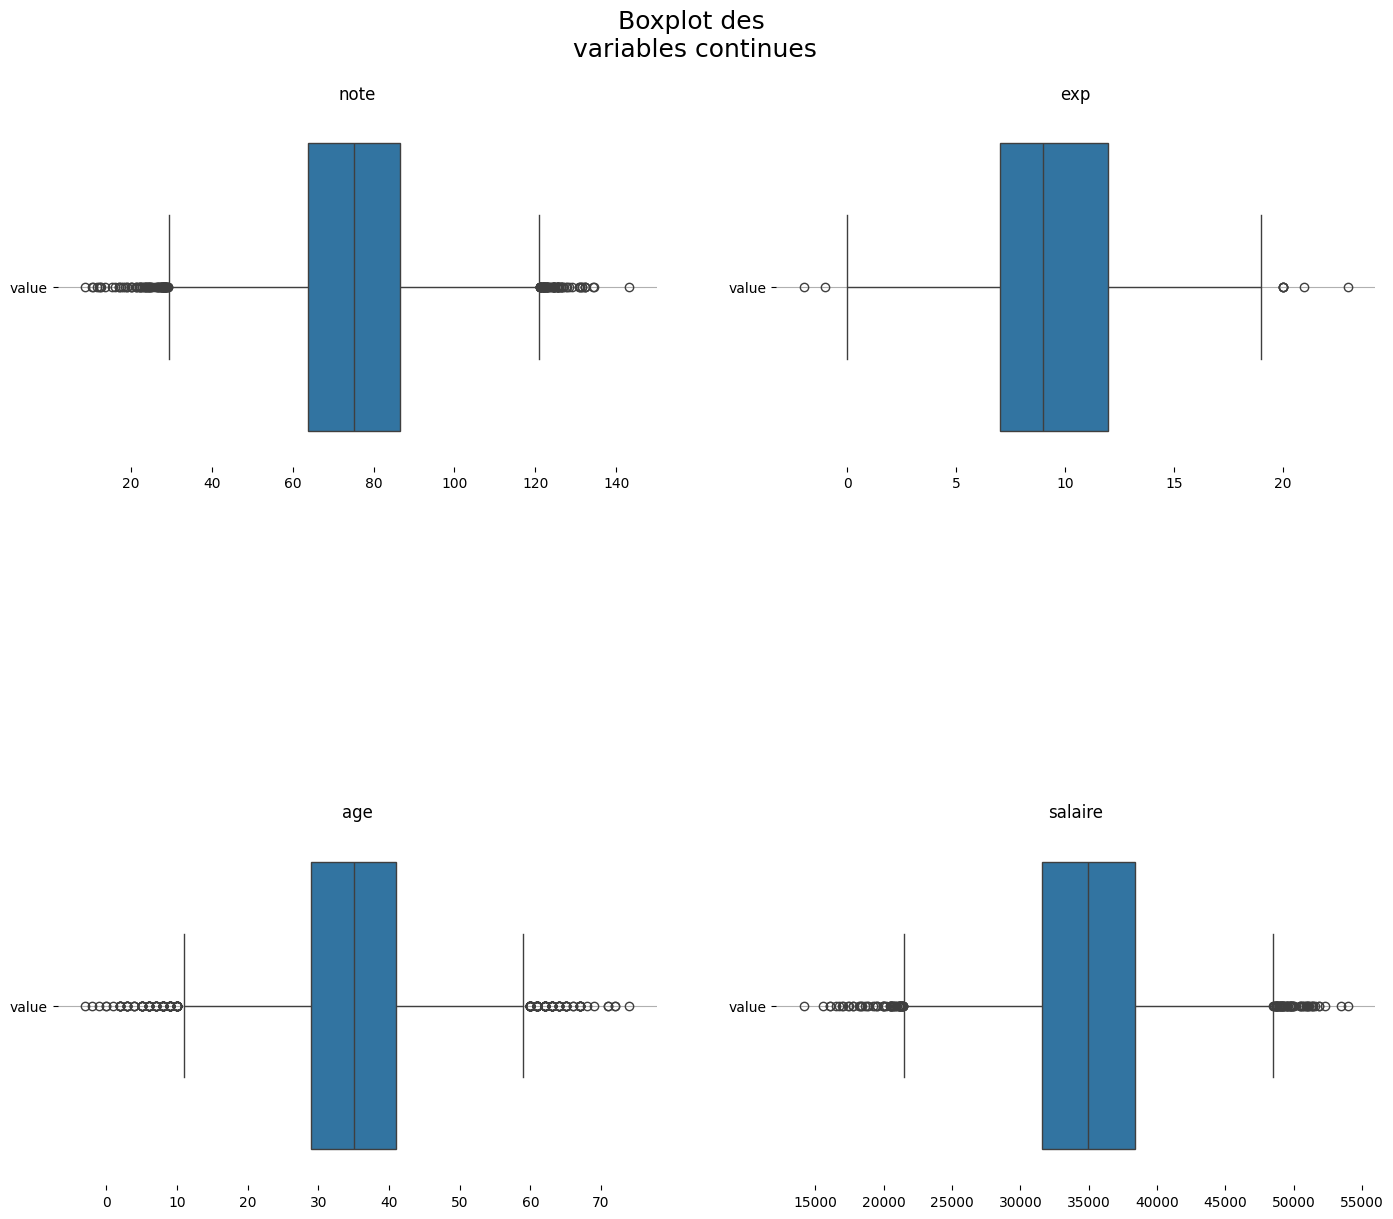

In [55]:
# On affiche les boxplots
temp=pd.melt(df[col_numericals].reset_index(), id_vars='index', value_vars=col_numericals).iloc[:,-2:]
 
ncols = 2
nrows = len(col_numericals) // ncols + (len(col_numericals) % ncols > 0)
 
plt.figure(figsize=(17, 14))
plt.subplots_adjust(hspace=1)
plt.suptitle("Boxplot des \nvariables continues", fontsize=18, y=0.95)
 
for n, variable in enumerate(col_numericals):
    # add a new subplot iteratively
    ax = plt.subplot(nrows, ncols, n + 1)
 
    sns.boxplot(ax=ax, data=temp[temp['variable']==variable], orient='h')
    #sns.kdeplot(ax=ax, data=temp[temp['variable']==variable], legend=None, palette=customPalette, shade=True)
    ax.grid(True, which='major', axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    ax.set_title(variable, loc= 'center', fontsize=12)

Les boxplots mettent en évidence la présence d’outliers dans toutes les variables continues. Ces valeurs extrêmes peuvent correspondre soit à des erreurs de saisie, soit à des observations réelles mais rares. Il faudra décider, lors du prétraitement, s’il est préférable de les conserver, de les corriger ou de les supprimer, selon l’impact qu’elles auront sur les modèles.

In [56]:
# EXERCICE : Completer cette fonction qui retourne 0 ou 1 si la valeur observée est outlier ou pas 
def is_outlier(df, column):
    # 1er Quartile 
    Q1 = df[column].quantile(0.25)
    
    # 3ème Quartile 
    Q3 = df[column].quantile(0.75)
    
    # Inter-Quartile Range (IQR)
    IQR = Q3 - Q1
    
    # limites, basse & haute
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    # Remplace les données inférieur et supérieur à la limite par 1 et les autres par 0
    series = ((df[column] < limite_inf) | (df[column] > limite_sup)).astype(int)
    
    return series


In [57]:
# EXERCICE : Appliquer votre fonction aux variables numeriques

for col in col_numericals:
    df[col + "_outlier"] = is_outlier(df, col)

# Vérification rapide : nb d'outliers par variable
print(df[[c for c in df.columns if "_outlier" in c]].sum())



note_outlier       149
exp_outlier          8
age_outlier        215
salaire_outlier    123
dtype: int64


L’analyse révèle la présence d’outliers surtout pour l’âge, la note et le salaire. Ces valeurs extrêmes peuvent influencer les résultats des modèles si elles ne sont pas traitées. L’expérience, en revanche, reste globalement homogène avec très peu d’outliers

In [58]:
# EXERCICE : Laissez libre court à votre créativité et créez une fonction qui affiche le taux et nombre
#            de valeurs manquantes de chaque variable
#            par ordre décroissant

def missing_summary(df):
    # Nombre de valeurs manquantes
    nb_missing = df.isnull().sum()
    
    # Taux de valeurs manquantes en %
    taux_missing = (df.isnull().sum() / len(df)) * 100
    
    # Regrouper dans un DataFrame
    missing_df = pd.DataFrame({
        'Nb_valeurs_manquantes': nb_missing,
        'Taux_valeurs_manquantes (%)': taux_missing
    })
    
    # Trier par ordre décroissant
    missing_df = missing_df[missing_df['Nb_valeurs_manquantes'] > 0] \
                           .sort_values(by='Nb_valeurs_manquantes', ascending=False)
    
    return missing_df

# Application
missing_summary(df)


,Nb_valeurs_manquantes,Taux_valeurs_manquantes (%)
note,114,0.570
diplome,109,0.545
exp,106,0.530
dispo,106,0.530
cheveux,105,0.525
salaire,105,0.525
age,101,0.505
sexe,100,0.500
specialite,93,0.465
date,91,0.455


### <span style="color:#011C5D">7. Encodage des variables categorielles </span>

In [59]:
# EXERCICE : Utiliser une methode adequate pour encoder les variables categorielles
import pandas as pd
import numpy as np

# === 1) Définir les colonnes catégorielles (hors cible) ===
cat_cols = ["cheveux", "diplome", "dispo", "sexe", "specialite"]

# === 2) Nettoyage léger des textes ===
for c in cat_cols:
    df[c] = (
        df[c]
        .astype("string")
        .str.strip()          # retire espaces autour
        .str.lower()          # met en minuscules
        .replace({"": pd.NA, " ": pd.NA})  # vide -> NaN
    )

# === 3) Imputation par le mode (on ne modifie pas les originales) ===
for c in cat_cols:
    mode_val = df[c].mode(dropna=True)[0]
    df[c + "_imputed_by_mode"] = df[c].fillna(mode_val)

# === 4) Encodage ordinal pour 'diplome' (ordre logique) ===
diplome_order = ["bac", "licence", "master", "doctorat"]
diplome_map = {d: i for i, d in enumerate(diplome_order, start=1)}  # bac=1 ... doctorat=4

df["diplome_encoded"] = (
    df["diplome_imputed_by_mode"]
    .map(diplome_map)         # mappe selon l'ordre défini
    .astype(int)
)

# === 5) One-Hot Encoding pour les autres catégorielles ===
nominal_cols = ["cheveux", "dispo", "sexe", "specialite"]

# On encode les versions imputées (pour éviter les NaN dans les dummies)
tmp = df[[c + "_imputed_by_mode" for c in nominal_cols]].copy()
tmp.columns = nominal_cols  # on remet les noms simples avant get_dummies

# drop_first=True pour éviter la colinéarité parfaite
ohe_df = pd.get_dummies(tmp, columns=nominal_cols, drop_first=True)

# === 6) Fusion : on ajoute les colonnes encodées au DataFrame ===
df_encoded = pd.concat([df, ohe_df], axis=1)

# === 7) Contrôles rapides ===
print("Colonnes créées (imputation par mode) :",
      [c for c in df.columns if c.endswith("_imputed_by_mode")])

print("Exemple de colonnes OHE ajoutées :",
      [c for c in ohe_df.columns][:10])

print("Aperçu :")
display(df_encoded.head())





Colonnes créées (imputation par mode) : ['cheveux_imputed_by_mode', 'diplome_imputed_by_mode', 'dispo_imputed_by_mode', 'sexe_imputed_by_mode', 'specialite_imputed_by_mode']
Exemple de colonnes OHE ajoutées : ['cheveux_brun', 'cheveux_chatain', 'cheveux_roux', 'dispo_oui', 'sexe_m', 'specialite_detective', 'specialite_forage', 'specialite_geologie']
Aperçu :


,date,cheveux,age,exp,salaire,sexe,diplome,specialite,note,dispo,...,salaire_outlier,diplome_encoded,cheveux_brun,cheveux_chatain,cheveux_roux,dispo_oui,sexe_m,specialite_detective,specialite_forage,specialite_geologie
0,02/06/2012,roux,25.0,9.0,26803.0,f,licence,geologie,97.08,non,...,0,2,False,False,True,False,False,False,False,True
1,21/04/2011,blond,35.0,13.0,38166.0,m,licence,forage,63.86,non,...,0,2,False,False,False,False,True,False,True,False
2,07/09/2012,blond,29.0,13.0,35207.0,m,licence,geologie,78.50,non,...,0,2,False,False,False,False,True,False,False,True
3,01/07/2011,brun,NaN,12.0,32442.0,m,licence,geologie,45.09,non,...,0,2,True,False,False,False,True,False,False,True
4,07/08/2012,roux,35.0,6.0,28533.0,f,licence,detective,81.91,non,...,0,2,False,False,True,False,False,True,False,False


### <span style="color:#011C5D">8. Encodage des variables categorielles Embedding </span>

In [60]:
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder

In [61]:
# Exemple variable
VARIABLE = "cheveux"
df[VARIABLE] = df[VARIABLE].fillna("Missing")
MODALITE = df[VARIABLE].unique()
NB_MODALITE = len(MODALITE)
NB_MODALITE,MODALITE

(5,
 <StringArray>
 ['roux', 'blond', 'brun', 'chatain', 'Missing']
 Length: 5, dtype: string)

In [62]:
DIM_EMBEDDING = 10

In [63]:
# Exemple d'embedding avec des weights aleatoire non entraine sur une dataset
embedding = nn.Embedding(NB_MODALITE, DIM_EMBEDDING)

In [64]:
df[VARIABLE+"_label_encoded"] = LabelEncoder().fit_transform(df[VARIABLE])

In [65]:
df[[VARIABLE,VARIABLE+"_label_encoded"]].head()

,cheveux,cheveux_label_encoded
0,roux,4
1,blond,1
2,blond,1
3,brun,2
4,roux,4


In [66]:
variable_to_torch = torch.tensor(df[VARIABLE+"_label_encoded"].values.tolist())  

In [67]:
embeddings = embedding(variable_to_torch)

In [68]:
embeddings

tensor([[ 0.8632, -0.2037, -1.3472,  ..., -0.7278, -0.7039, -1.8370],
        [-0.7053, -0.5094,  1.4626,  ..., -0.4401,  1.4846, -0.6887],
        [-0.7053, -0.5094,  1.4626,  ..., -0.4401,  1.4846, -0.6887],
        ...,
        [-1.5402, -1.2504,  0.0561,  ..., -0.8610,  0.7149, -1.3920],
        [-1.5402, -1.2504,  0.0561,  ..., -0.8610,  0.7149, -1.3920],
        [-0.1373,  0.6810, -0.3316,  ...,  0.3665, -1.5030,  0.9094]],
       grad_fn=<EmbeddingBackward0>)

In [69]:
embeddings.shape

torch.Size([20000, 10])

In [70]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

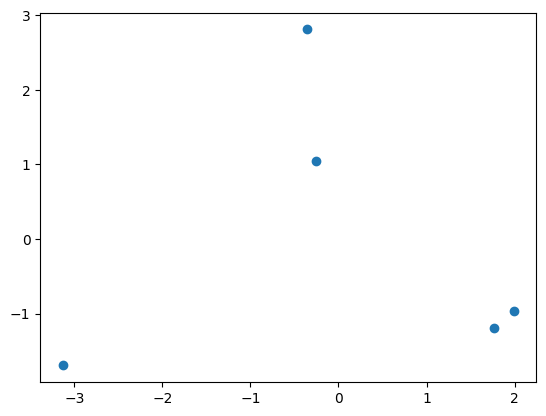

In [71]:
### Visualisation des embeddings
embeddings_weight = embedding.weight.data.numpy()
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings_weight)


plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1])
plt.show()

### <span style="color:#011C5D">9. Créer votre package python </span>

    - Step 1 : Créer un fichier analyse_exploratoire.py
    - Step 2 : Copier toutes les fonctions de ce notebook dans votre fichier fichier analyse_exploratoire.py
    - Step 3 : Créer un dossier src
    - Step 4 : Deplacer votre fichier analyse_exploratoire.py dans le dossier src
    - Step 5 : Créer un nouveau notebook
    - Step 6 : Dans ce notebook, specifier le chemin vers votre dossier src
    - Step 7 : Executer 'from  analyse_exploratoire import is_outlier, display_missing_values etc...
    - Step 8 : Analyser vos données avec ces nouvelles fonction

## Ressources

Imputation:

- [Imputation Iterrative](https://scikit-learn.org/stable/auto_examples/impute/plot_iterative_imputer_variants_comparison.html) 
- [Imputation](https://scikit-learn.org/stable/modules/impute.html) 

Outliers:

- [Doc sklearn](https://scikit-learn.org/stable/modules/outlier_detection.html)
- [Doc Medium](https://towardsdatascience.com/5-outlier-detection-methods-that-every-data-enthusiast-must-know-f917bf439210)